# 🏥 Obesity Predictors – Multi-Variable Analysis
> **Dataset:** ObesityDataSet_raw_and_data_sinthetic.csv  

---


## 1. Setup & Data Loading

In [25]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings; warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
print('Shape:', df.shape)
df.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [27]:
print(df.dtypes)
print('\nClass counts:\n', df['NObeyesdad'].value_counts())

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

Class counts:
 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


## 2. Target Variable
Target **NObeyesdad** (obesity level) 

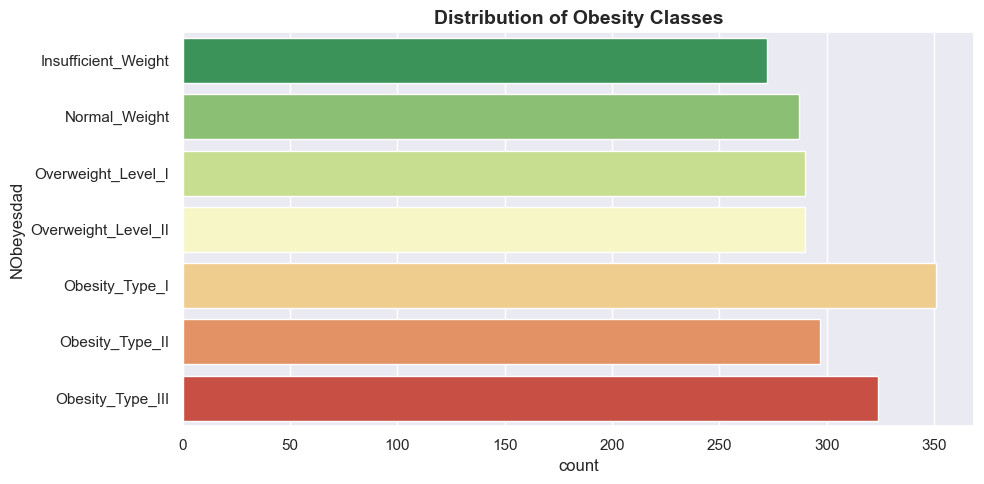

In [28]:
obesity_order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I',
                 'Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

df['ObesityLevel'] = df['NObeyesdad'].map({o:i for i,o in enumerate(obesity_order)})

f, ax = plt.subplots(figsize=(10,5))
sb.countplot(data=df, y='NObeyesdad', order=obesity_order, palette='RdYlGn_r', ax=ax)
ax.set_title('Distribution of Obesity Classes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

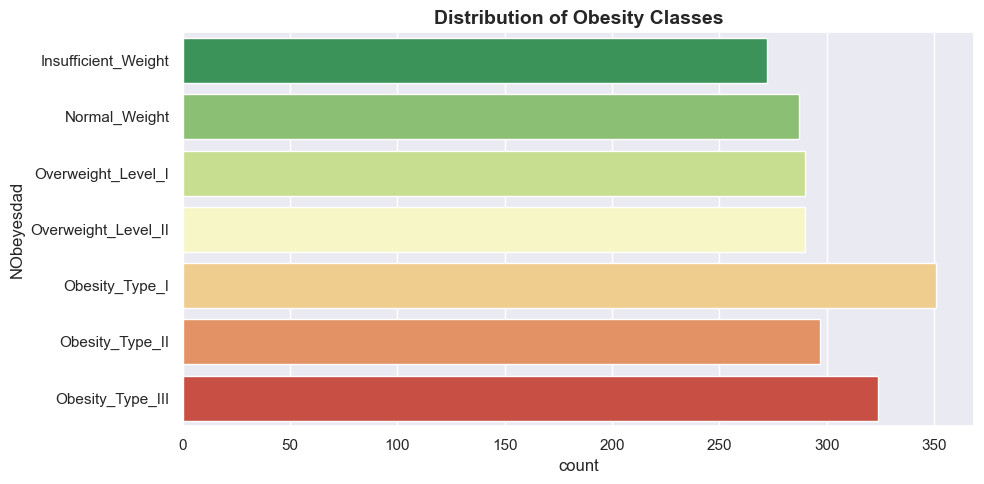

In [29]:

df['ObesityLevel'] = df['NObeyesdad'].map({o:i for i,o in enumerate(obesity_order)})

f, ax = plt.subplots(figsize=(10,5))
sb.countplot(data=df, y='NObeyesdad', order=obesity_order, palette='RdYlGn_r', ax=ax)
ax.set_title('Distribution of Obesity Classes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Numeric Variable Correlations
Correlation between all numeric features and the **ObesityLevel** score.

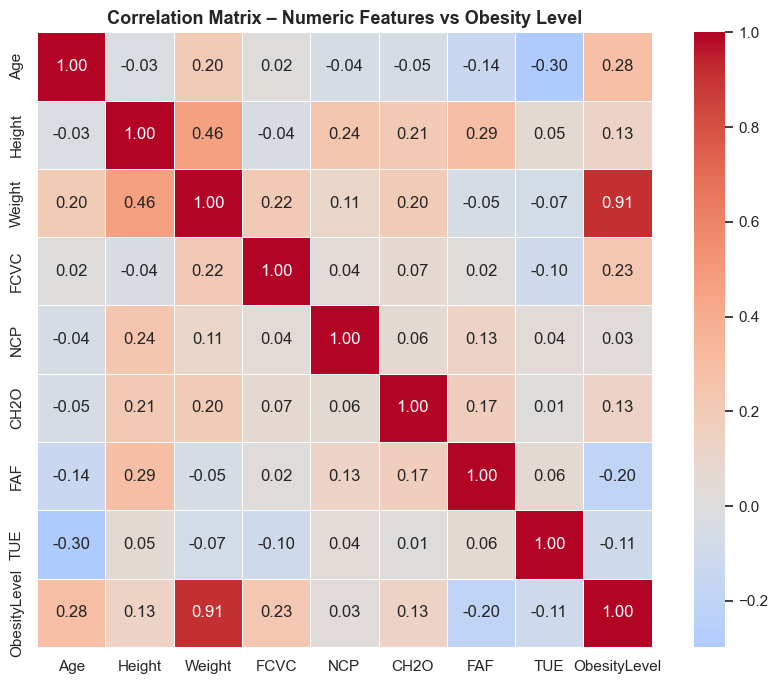


Top correlates with ObesityLevel:
Weight    0.913251
Age       0.282913
FCVC      0.227759
FAF      -0.199901
Height    0.133565
CH2O      0.133008
TUE      -0.107991
NCP       0.026690
Name: ObesityLevel, dtype: float64


In [30]:
num_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE','ObesityLevel']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
sb.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix – Numeric Features vs Obesity Level', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTop correlates with ObesityLevel:')
print(corr['ObesityLevel'].drop('ObesityLevel').sort_values(key=abs, ascending=False))

**Key findings:**
- **Weight** has the strongest positive correlation with obesity level (expected, but confirms data quality)
- **Height** is negatively correlated (taller individuals at same weight → lower BMI equivalent)
- **FAF** (physical activity frequency) is negatively correlated – more exercise → lower obesity
- **TUE** (technology/sedentary time) shows a moderate positive correlation
- **Age** shows a weak positive trend


## 4. Key Numeric Predictors – Boxplots by Class
Visualise how each numeric variable distributes across obesity categories.

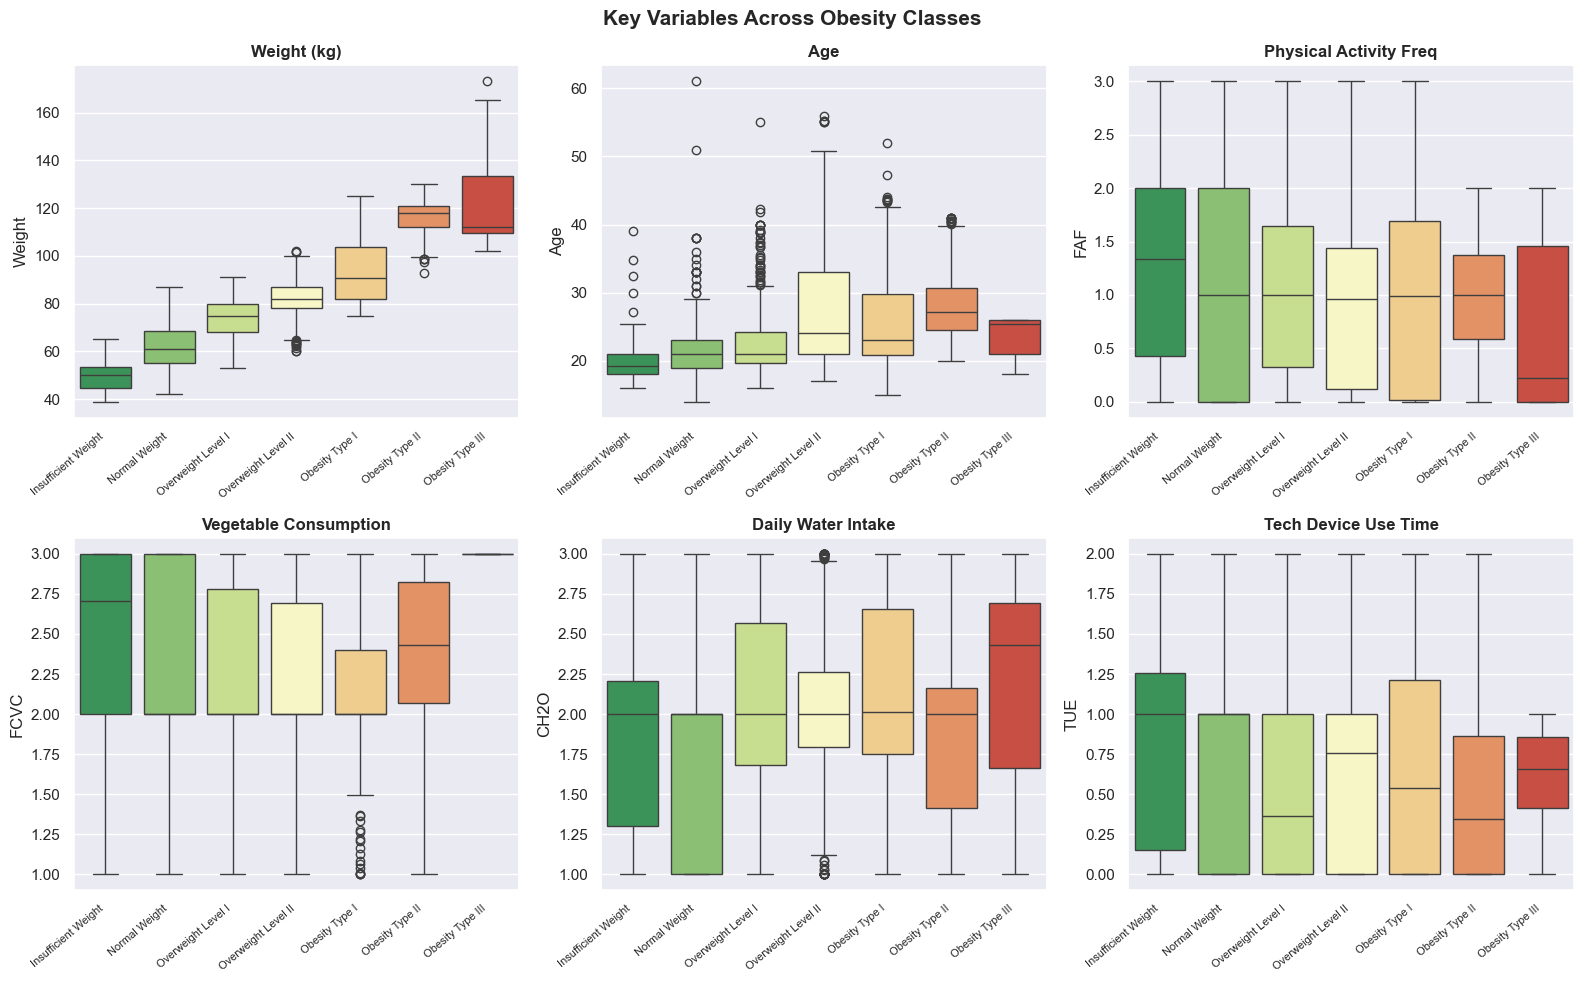

In [31]:
vars_to_plot = [('Weight','Weight (kg)'),('Age','Age'),('FAF','Physical Activity Freq'),
                ('FCVC','Vegetable Consumption'),('CH2O','Daily Water Intake'),('TUE','Tech Device Use Time')]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (col, label) in zip(axes.flatten(), vars_to_plot):
    sb.boxplot(data=df, x='NObeyesdad', y=col, order=obesity_order, palette='RdYlGn_r', ax=ax)
    ax.set_xticklabels([o.replace('_',' ') for o in obesity_order], rotation=40, ha='right', fontsize=8)
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('')
plt.suptitle('Key Variables Across Obesity Classes', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Categorical Predictors – Stacked Bar Charts
See how lifestyle/behavioural categorical variables distribute across obesity classes.

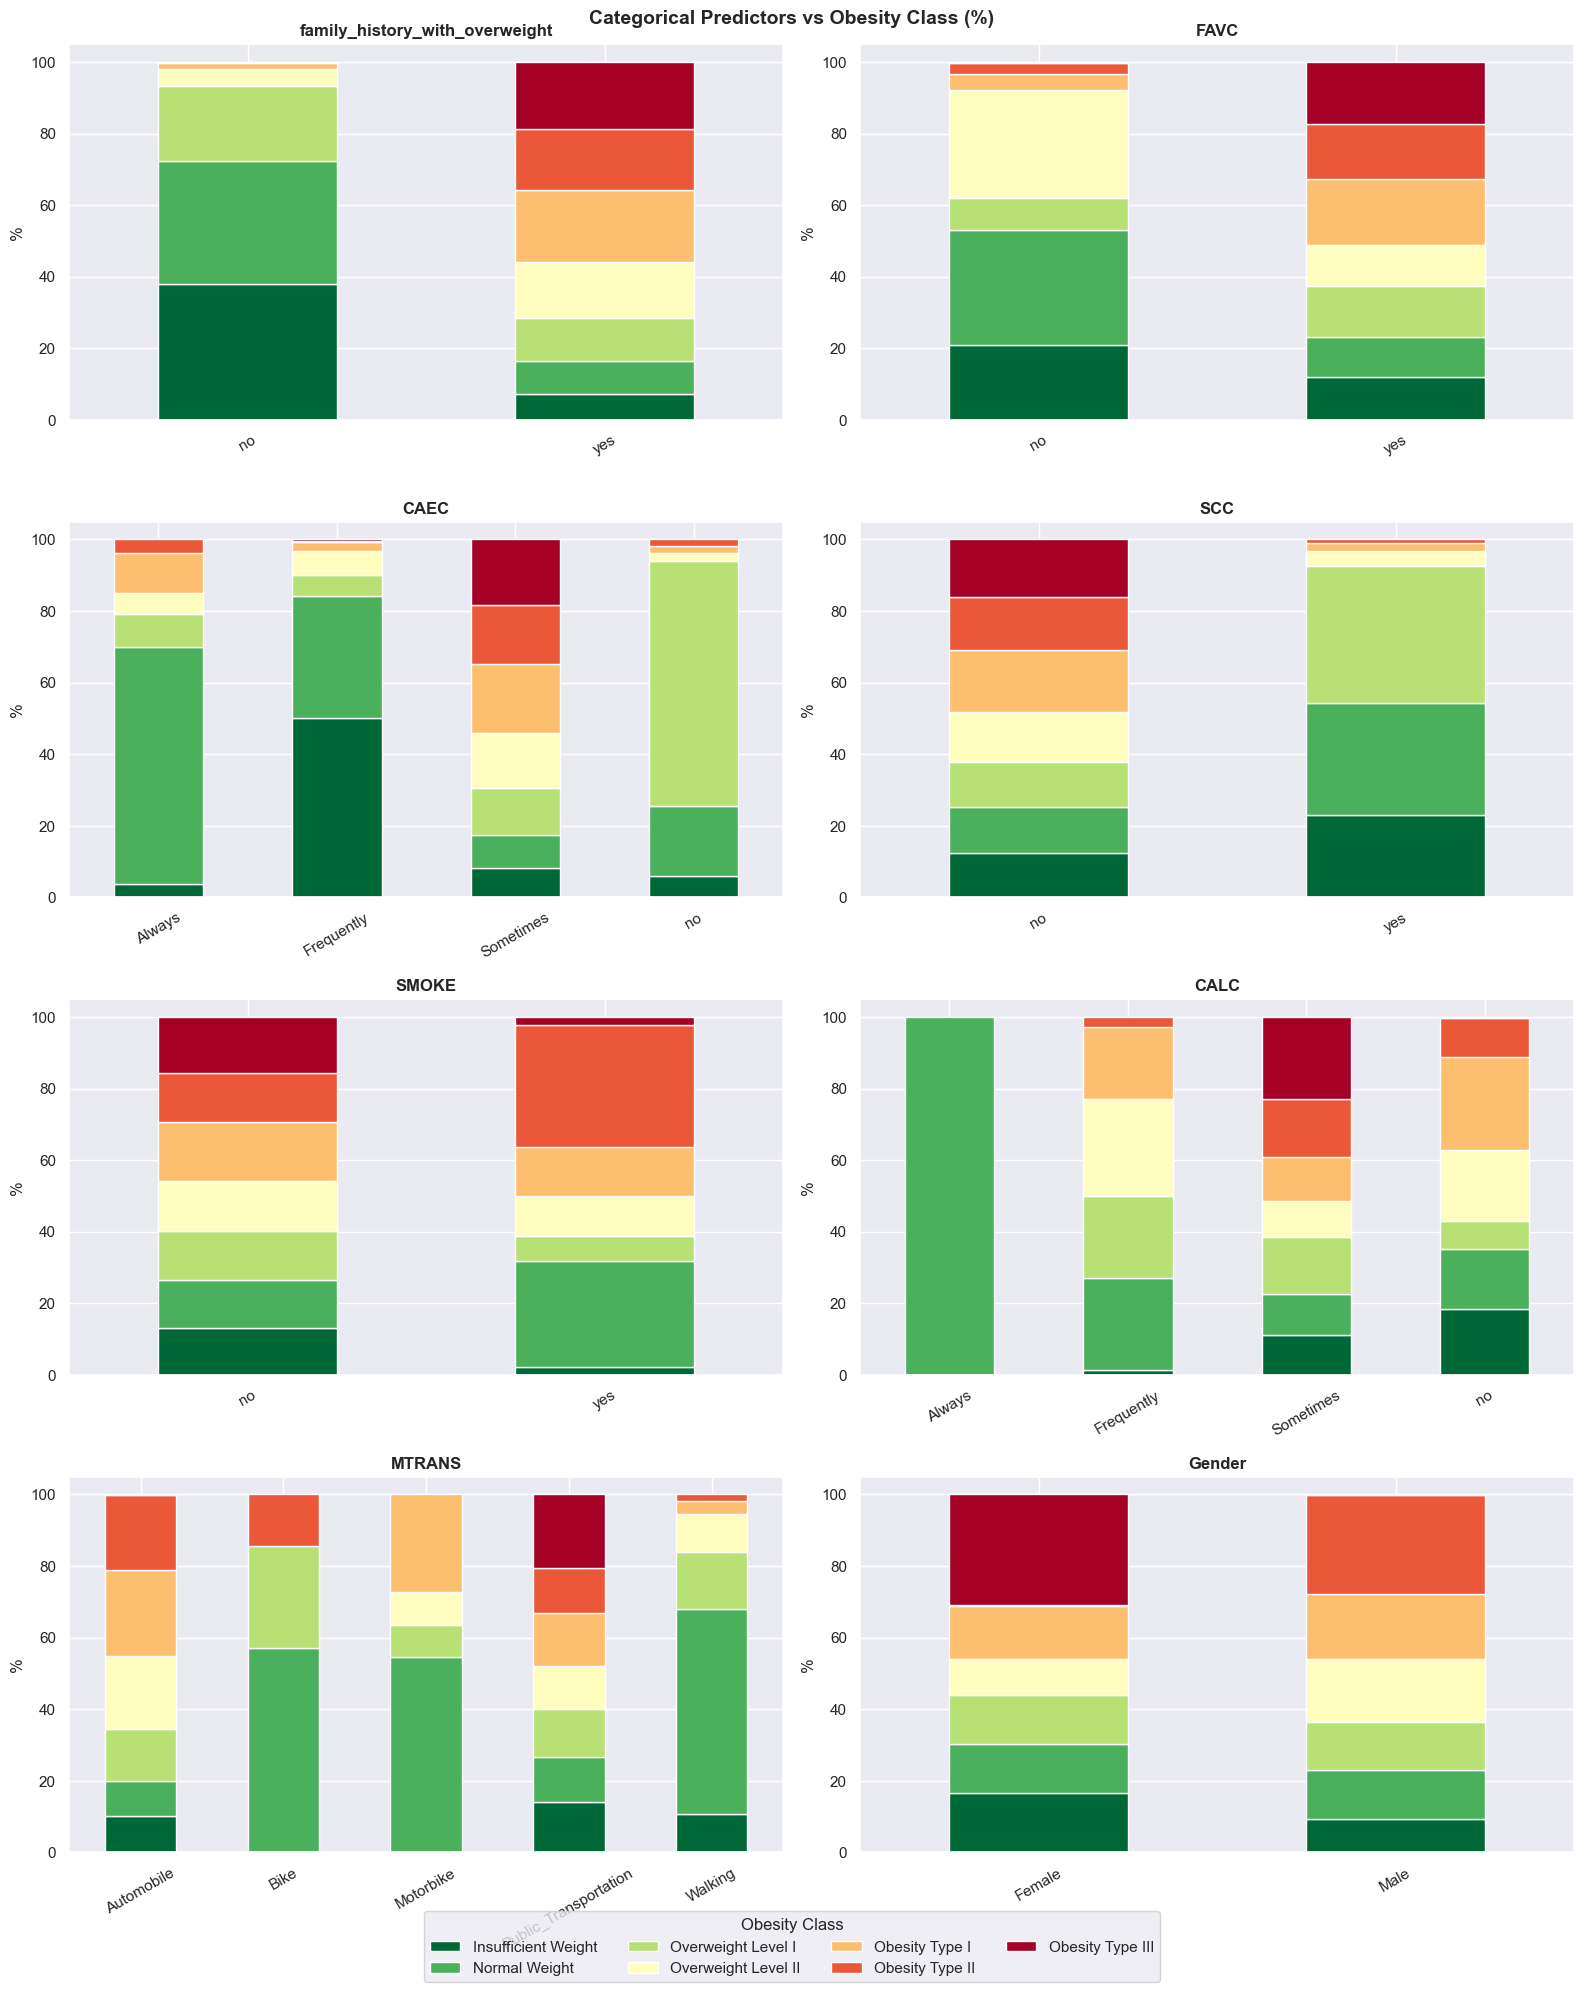

In [32]:
cat_vars = ['family_history_with_overweight','FAVC','CAEC','SCC','SMOKE','CALC','MTRANS','Gender']
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for ax, col in zip(axes.flatten(), cat_vars):
    ct = pd.crosstab(df[col], df['NObeyesdad'], normalize='index')[obesity_order]*100
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r', legend=False)
    ax.set_title(col, fontweight='bold'); ax.set_ylabel('%'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, [o.replace('_',' ') for o in obesity_order],
           loc='lower center', ncol=4, title='Obesity Class', bbox_to_anchor=(0.5,-0.01))
plt.suptitle('Categorical Predictors vs Obesity Class (%)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Scatter Plot – Weight vs Height by Obesity Class

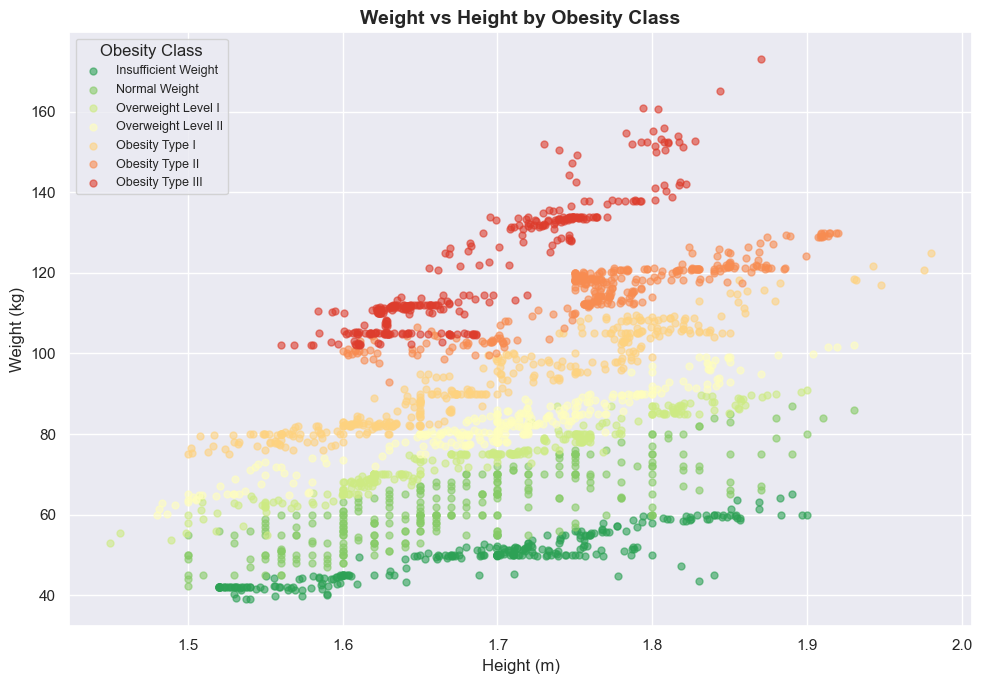

In [33]:
palette = sb.color_palette('RdYlGn_r', n_colors=7)
color_map = dict(zip(obesity_order, palette))

fig, ax = plt.subplots(figsize=(10,7))
for cls in obesity_order:
    sub = df[df['NObeyesdad']==cls]
    ax.scatter(sub['Height'], sub['Weight'], label=cls.replace('_',' '),
               color=color_map[cls], alpha=0.6, s=25)
ax.set_xlabel('Height (m)', fontsize=12); ax.set_ylabel('Weight (kg)', fontsize=12)
ax.set_title('Weight vs Height by Obesity Class', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, title='Obesity Class')
plt.tight_layout(); plt.show()

## 7. Multi-Variable Decision Tree Classifier


In [34]:
obesity_order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I',
                 'Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

# Ordinal numeric target (used for regression)
df['ObesityLevel'] = df['NObeyesdad'].map({o: i for i, o in enumerate(obesity_order)})

# Full label-encoded copy (used for classification)
df_enc = df.copy()
le = LabelEncoder()
for col in df.select_dtypes('object').columns:
    df_enc[col] = le.fit_transform(df[col])

features = ['Age','Weight','Height','FAF','FCVC','CH2O','TUE','NCP',
            'family_history_with_overweight','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS','Gender']

X = df_enc[features]
y_cls = df_enc['NObeyesdad']   # for classification
y_reg = df['ObesityLevel']     # for regression

X_train, X_test, y_cls_train, y_cls_test = train_test_split(X, y_cls, test_size=0.25, random_state=42)
_, _, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.25, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 1583 | Test: 528


In [35]:
# Shallow tree (depth=9) — interpretable
dt3 = DecisionTreeClassifier(max_depth=9, random_state=42)
dt3.fit(X_train, y_cls_train)
print(f'Train Accuracy (depth=9): {dt3.score(X_train, y_cls_train):.3f}')
print(f'Test  Accuracy (depth=9): {dt3.score(X_test,  y_cls_test):.3f}')

Train Accuracy (depth=9): 0.997
Test  Accuracy (depth=9): 0.920


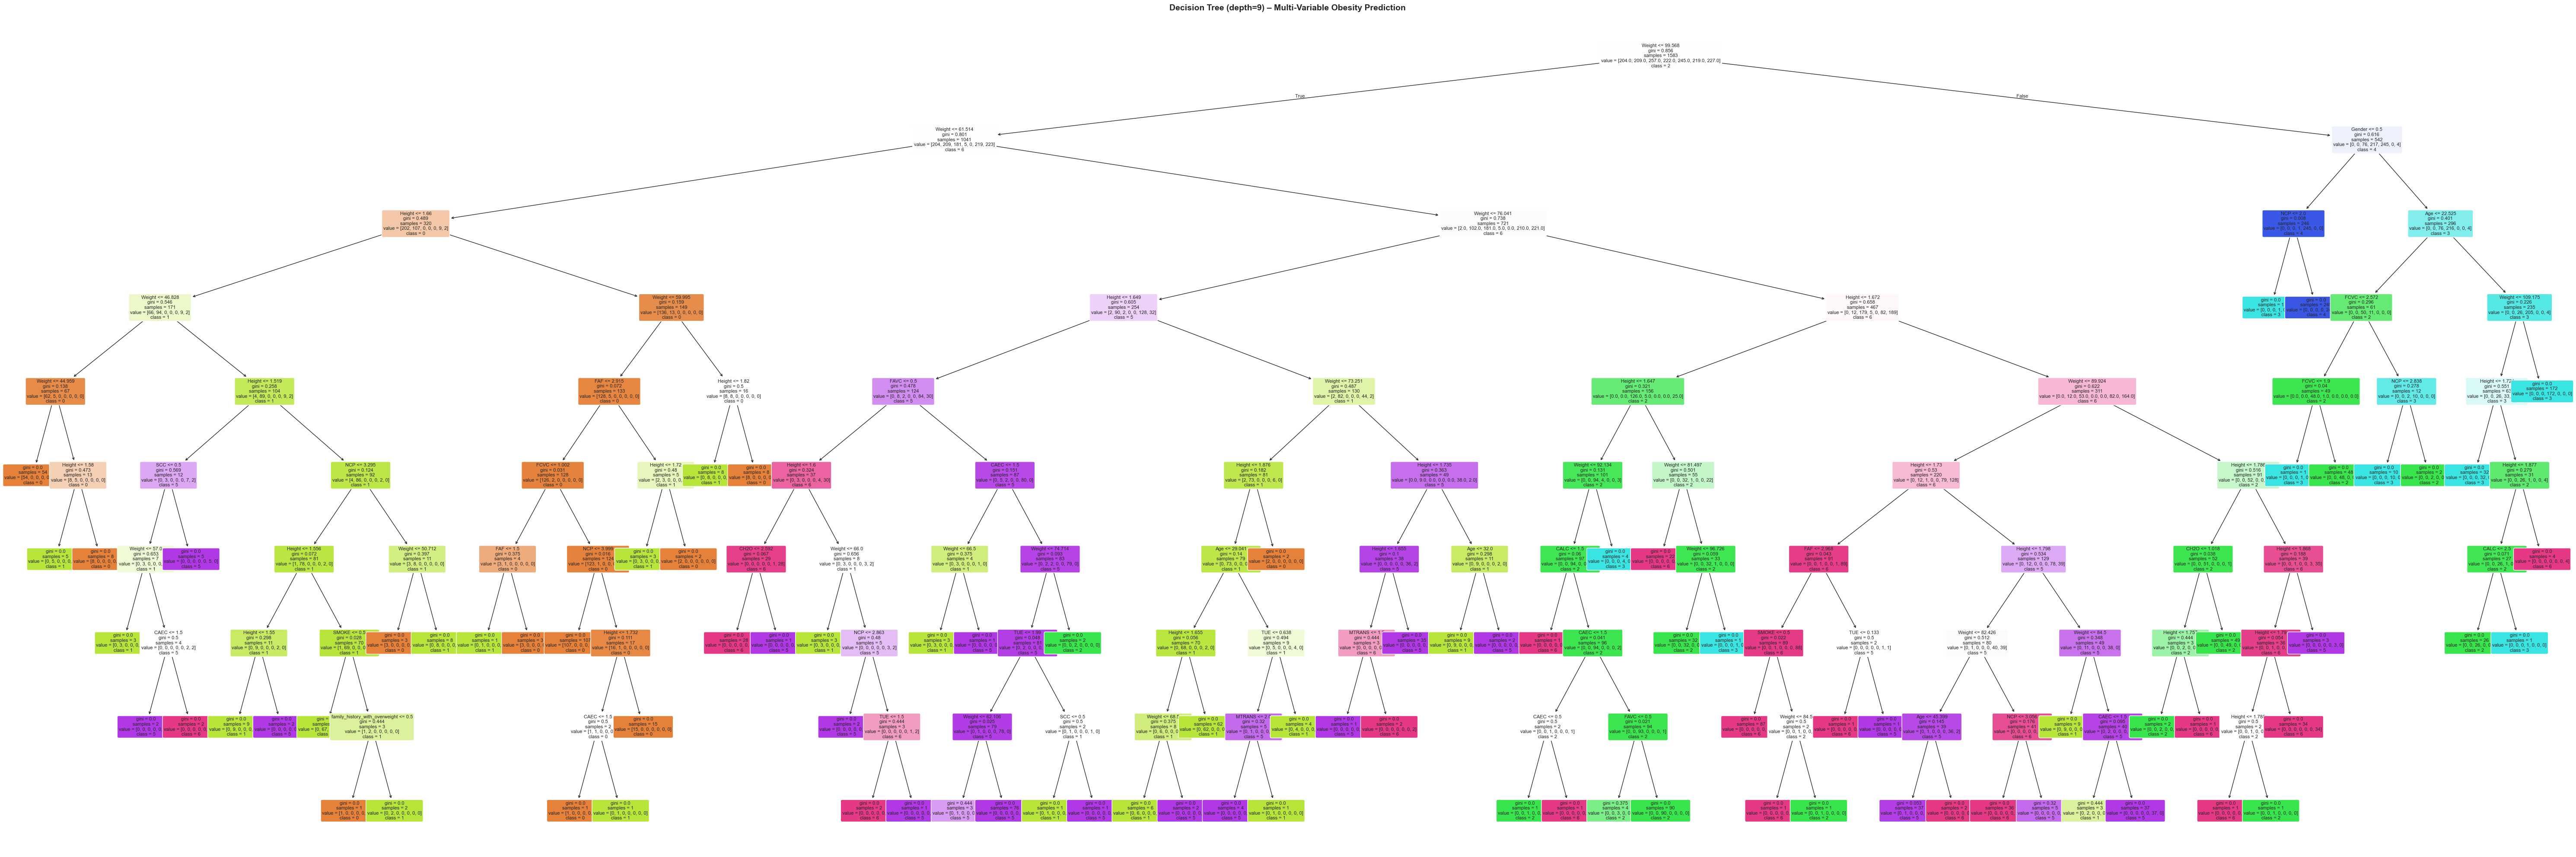

In [36]:
fig, ax = plt.subplots(figsize=(60, 20))
plot_tree(dt3, feature_names=features,
          class_names=[str(c) for c in dt3.classes_],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (depth=9) – Multi-Variable Obesity Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

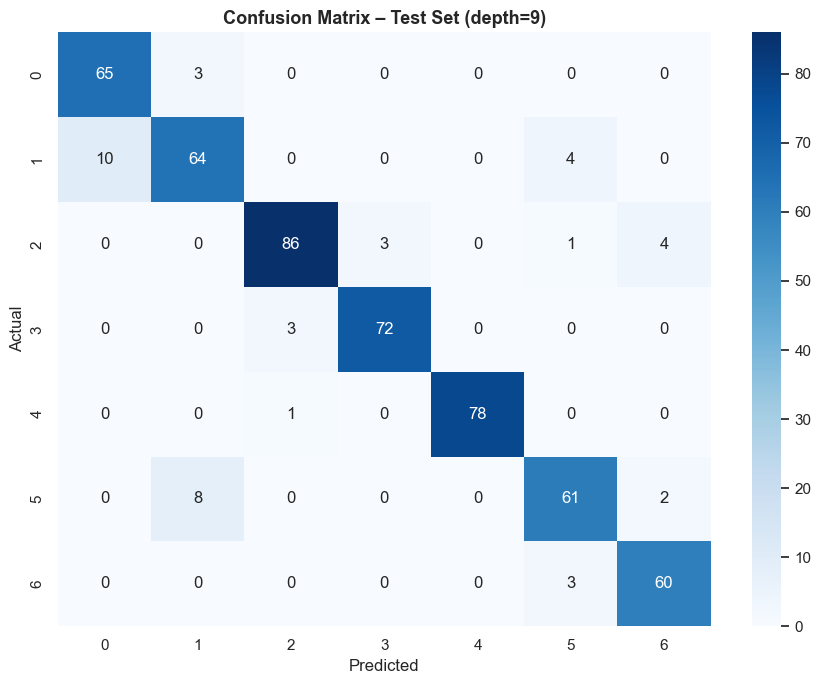

In [37]:
# Confusion matrix on test set
y_pred = dt3.predict(X_test)
cm = confusion_matrix(y_cls_test, y_pred)
fig, ax = plt.subplots(figsize=(9,7))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=[str(c) for c in dt3.classes_],
           yticklabels=[str(c) for c in dt3.classes_], ax=ax)
ax.set_title(f'Confusion Matrix – Test Set (depth=9)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


## 8. Feature Importance
Using a deeper tree (depth=10) to get richer importance scores across all 16 features.

In [38]:
dt10 = DecisionTreeClassifier(max_depth=10, random_state=42)
dt10.fit(X_train, y_cls_train)
print(f'Train Accuracy (depth=10): {dt10.score(X_train, y_cls_train):.3f}')
print(f'Test  Accuracy (depth=10): {dt10.score(X_test,  y_cls_test):.3f}')

fi = pd.Series(dt10.feature_importances_, index=features).sort_values(ascending=False)
print('\nFeature Importances:\n', fi.round(4).to_string())

Train Accuracy (depth=10): 0.999
Test  Accuracy (depth=10): 0.919

Feature Importances:
 Weight                            0.4806
Height                            0.2240
Gender                            0.1572
Age                               0.0440
FAVC                              0.0256
CALC                              0.0207
FCVC                              0.0129
CAEC                              0.0076
NCP                               0.0069
FAF                               0.0069
TUE                               0.0045
CH2O                              0.0044
family_history_with_overweight    0.0027
SCC                               0.0017
SMOKE                             0.0005
MTRANS                            0.0000


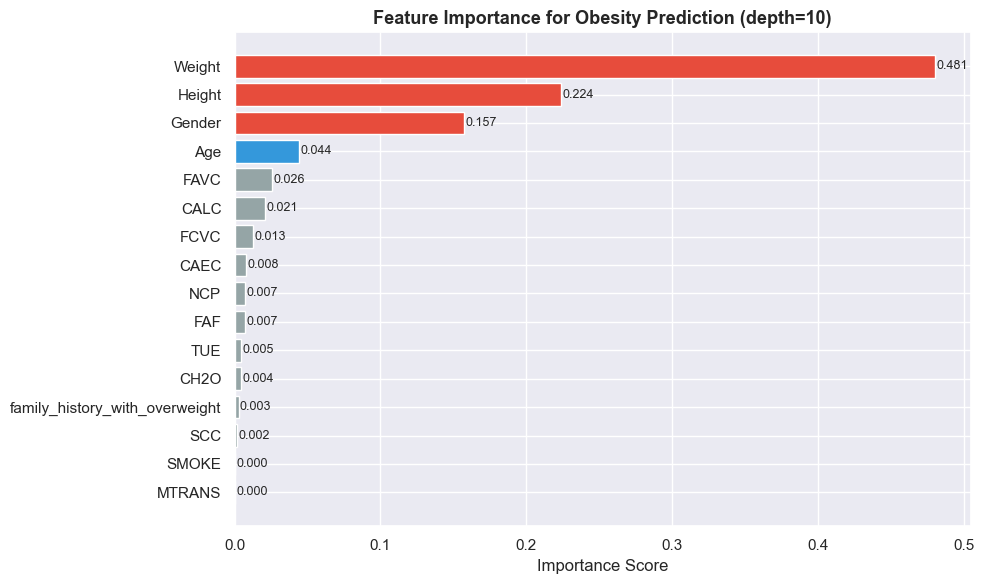

In [39]:
fig, ax = plt.subplots(figsize=(10,6))
colors = ['#e74c3c' if v > 0.1 else '#3498db' if v > 0.03 else '#95a5a6' for v in fi.values]
ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance for Obesity Prediction (depth=10)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i,(name,val) in enumerate(zip(fi.index[::-1], fi.values[::-1])):
    ax.text(val+0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 9. Random Forest – Regression
> **Goal:** Predict the *ordinal numeric* obesity level (0–6) as a continuous value.  
> Random Forest builds many decorrelated decision trees and averages their predictions,  
> reducing variance compared to a single tree.  
> We evaluate with **RMSE** and **R²** and also look at feature importances.

In [40]:
# ── Train ──
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=None,
                               random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)

y_pred_reg = rf_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2   = r2_score(y_reg_test, y_pred_reg)
print(f'Random Forest Regression  |  RMSE: {rmse:.4f}  |  R²: {r2:.4f}')

# Rounded predictions → class accuracy proxy
rounded_acc = np.mean(np.round(y_pred_reg).clip(0,6) == y_reg_test)
print(f'Rounded-to-class accuracy: {rounded_acc:.4f}')

Random Forest Regression  |  RMSE: 0.2026  |  R²: 0.9897
Rounded-to-class accuracy: 0.9527


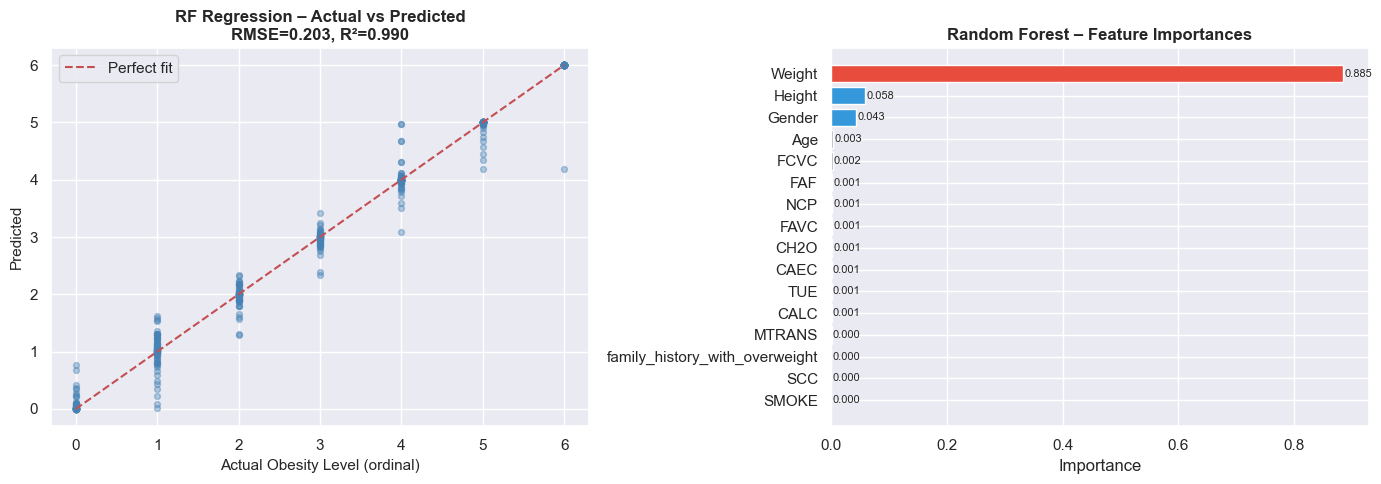

In [41]:
# ── Actual vs Predicted scatter ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_reg_test, y_pred_reg, alpha=0.4, s=18, color='steelblue')
ax.plot([0,6],[0,6], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Obesity Level (ordinal)', fontsize=11)
ax.set_ylabel('Predicted', fontsize=11)
ax.set_title(f'RF Regression – Actual vs Predicted\nRMSE={rmse:.3f}, R²={r2:.3f}',
             fontweight='bold')
ax.legend()

# ── Feature importances ──
ax = axes[1]
fi = pd.Series(rf_reg.feature_importances_, index=features).sort_values()
colors = ['#e74c3c' if v > 0.10 else '#3498db' if v > 0.03 else '#95a5a6'
          for v in fi.values]
ax.barh(fi.index, fi.values, color=colors, edgecolor='white')
ax.set_title('Random Forest – Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')
for i, (name, val) in enumerate(zip(fi.index, fi.values)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

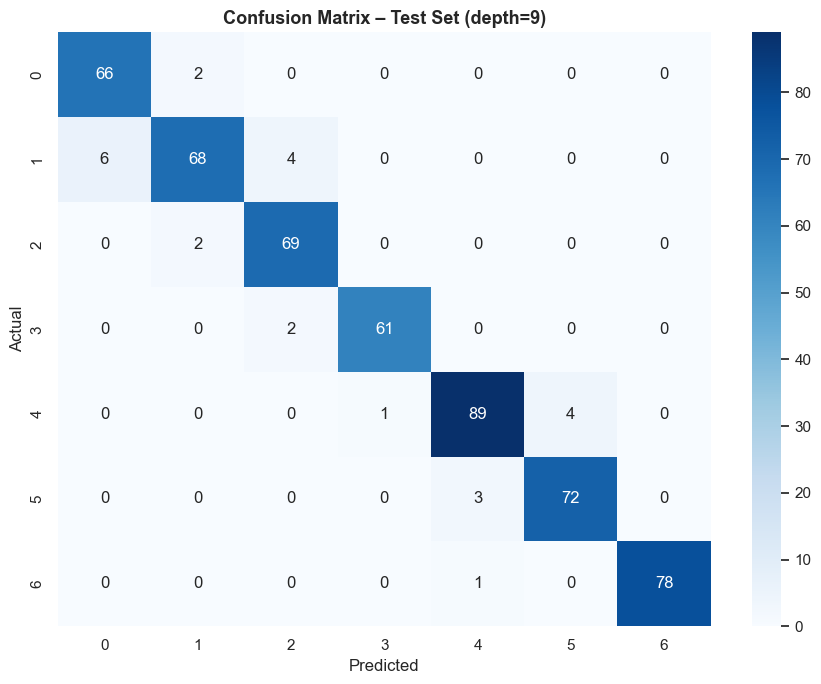

In [42]:
# Confusion matrix on test set
y_pred = dt3.predict(X_test)
cm = confusion_matrix(y_reg_test, y_pred_reg .round().clip(0,6))
fig, ax = plt.subplots(figsize=(9,7))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=[str(c) for c in dt3.classes_],
           yticklabels=[str(c) for c in dt3.classes_], ax=ax)
ax.set_title(f'Confusion Matrix – Test Set (depth=9)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 10. Linear Regression – Obesity Level



In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ── Train ──
lr = LinearRegression()
lr.fit(X_train, y_reg_train)

y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
r2_lr   = r2_score(y_reg_test, y_pred_lr)
rounded_acc_lr = np.mean(np.round(y_pred_lr).clip(0, 6) == y_reg_test)

print(f'Linear Regression  |  RMSE: {rmse_lr:.4f}  |  R²: {r2_lr:.4f}')
print(f'Rounded-to-class accuracy: {rounded_acc_lr:.4f}')


Linear Regression  |  RMSE: 0.4385  |  R²: 0.9515
Rounded-to-class accuracy: 0.8220


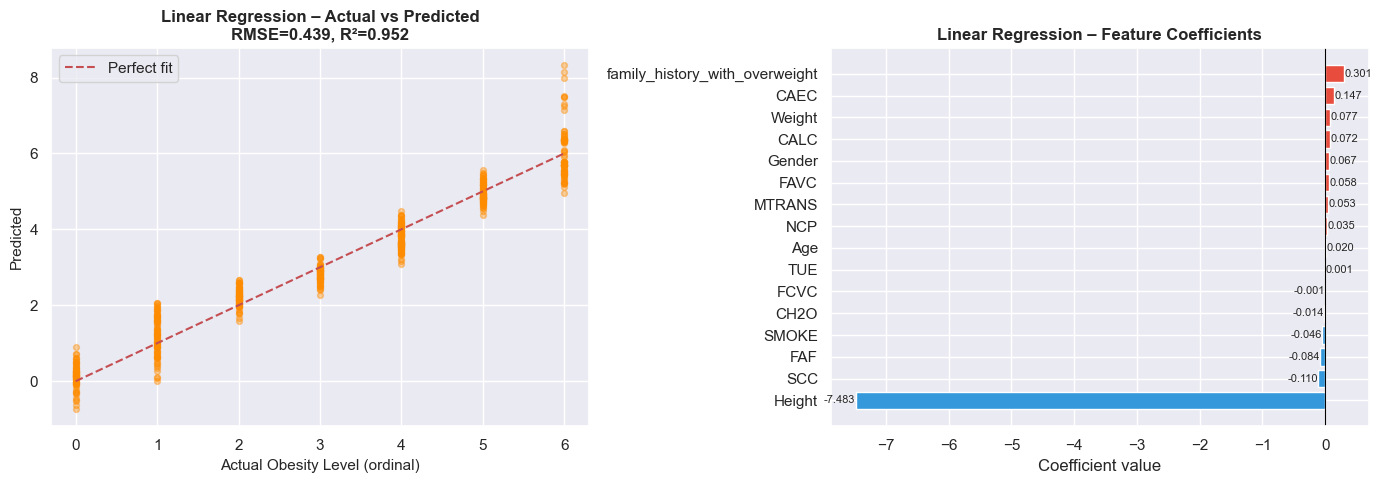

In [44]:
# ── Actual vs Predicted + Coefficient bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_reg_test, y_pred_lr, alpha=0.4, s=18, color='darkorange')
ax.plot([0, 6], [0, 6], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Obesity Level (ordinal)', fontsize=11)
ax.set_ylabel('Predicted', fontsize=11)
ax.set_title(f'Linear Regression – Actual vs Predicted\nRMSE={rmse_lr:.3f}, R²={r2_lr:.3f}',
             fontweight='bold')
ax.legend()

# ── Coefficients ──
ax = axes[1]
coef_series = pd.Series(lr.coef_, index=features).sort_values()
colors_coef = ['#e74c3c' if v > 0 else '#3498db' for v in coef_series.values]
ax.barh(coef_series.index, coef_series.values, color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression – Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient value')
for i, (name, val) in enumerate(zip(coef_series.index, coef_series.values)):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, i, f'{val:.3f}', va='center', fontsize=8,
            ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.show()


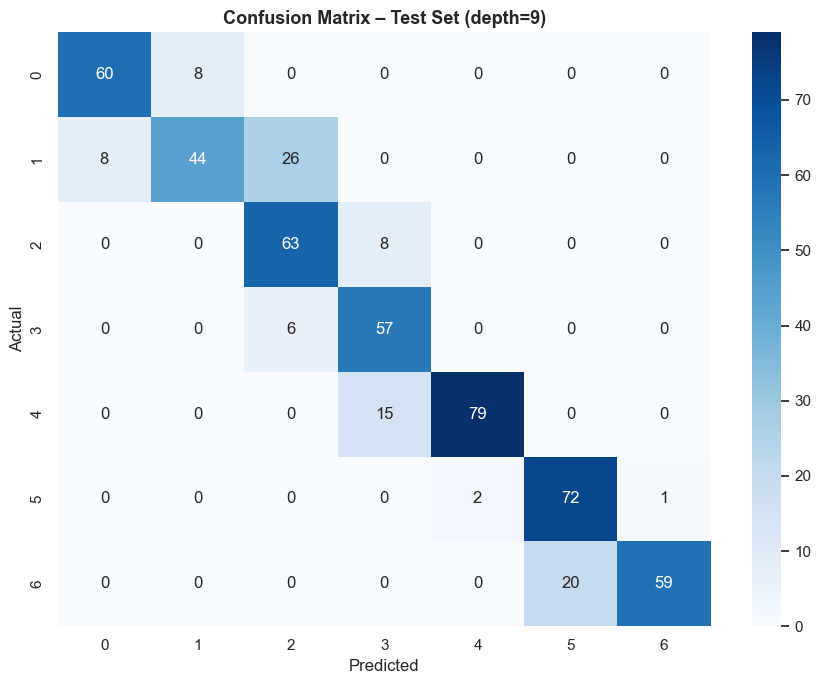

In [45]:
# Confusion matrix on test set
y_pred = dt3.predict(X_test)
cm = confusion_matrix(y_reg_test, y_pred_lr .round().clip(0,6))
fig, ax = plt.subplots(figsize=(9,7))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=[str(c) for c in dt3.classes_],
           yticklabels=[str(c) for c in dt3.classes_], ax=ax)
ax.set_title(f'Confusion Matrix – Test Set (depth=9)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 11. Model Comparison – Decision Tree vs Random Forest vs Linear Regression
We compare all three models on the test set using RMSE, R², and a class-accuracy proxy
(predictions rounded to the nearest integer class 0–6).


In [46]:
# ── Re-collect regression metrics for DT (depth=9) in ordinal mode ──
y_pred_dt_reg = dt3.predict(X_test)          # class labels (strings/ints)
# Convert DT class predictions to ordinal integers for fair regression comparison
label_to_ord = {o: i for i, o in enumerate(obesity_order)}
y_pred_dt_ord = np.array([label_to_ord.get(str(p), p) for p in y_pred_dt_reg])

rmse_dt  = np.sqrt(mean_squared_error(y_reg_test, y_pred_dt_ord))
r2_dt    = r2_score(y_reg_test, y_pred_dt_ord)
acc_dt   = np.mean(y_pred_dt_ord == y_reg_test.values)

# RF regression metrics (already computed in §9)
rmse_rf  = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2_rf    = r2_score(y_reg_test, y_pred_reg)
acc_rf   = np.mean(np.round(y_pred_reg).clip(0, 6) == y_reg_test)

# Linear Regression metrics (computed in §10)
# rmse_lr, r2_lr, rounded_acc_lr already defined above

results = pd.DataFrame({
    'Model':    ['Decision Tree (depth=9)', 'Random Forest (200 trees)', 'Linear Regression'],
    'RMSE':     [rmse_dt, rmse_rf, rmse_lr],
    'R²':       [r2_dt,   r2_rf,   r2_lr],
    'Class Acc':[acc_dt,  acc_rf,  rounded_acc_lr],
})
print(results.to_string(index=False, float_format='{:.4f}'.format))


                    Model   RMSE      R²  Class Acc
  Decision Tree (depth=9) 2.0528 -0.0619     0.2443
Random Forest (200 trees) 0.2026  0.9897     0.9527
        Linear Regression 0.4385  0.9515     0.8220


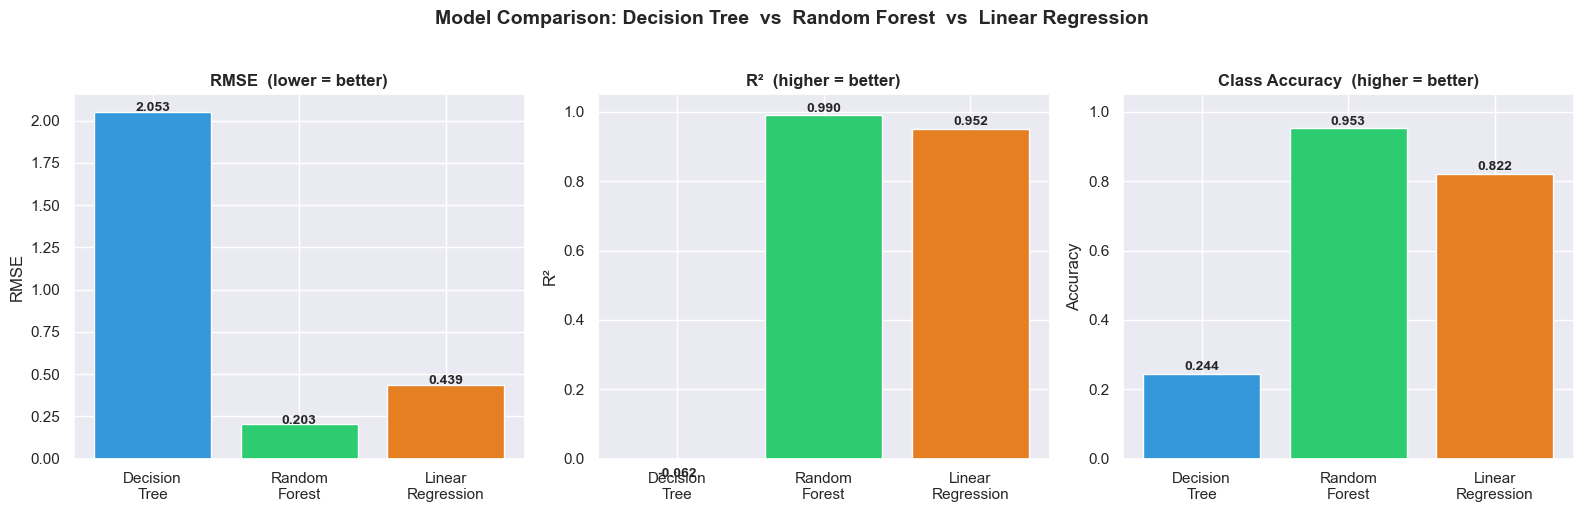

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models  = ['Decision\nTree', 'Random\nForest', 'Linear\nRegression']
palette = ['#3498db', '#2ecc71', '#e67e22']

# RMSE (lower is better)
axes[0].bar(models, [rmse_dt, rmse_rf, rmse_lr], color=palette, edgecolor='white')
axes[0].set_title('RMSE  (lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
for i, v in enumerate([rmse_dt, rmse_rf, rmse_lr]):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# R² (higher is better)
axes[1].bar(models, [r2_dt, r2_rf, r2_lr], color=palette, edgecolor='white')
axes[1].set_title('R²  (higher = better)', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate([r2_dt, r2_rf, r2_lr]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Class Accuracy (higher is better)
axes[2].bar(models, [acc_dt, acc_rf, rounded_acc_lr], color=palette, edgecolor='white')
axes[2].set_title('Class Accuracy  (higher = better)', fontweight='bold')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1.05)
for i, v in enumerate([acc_dt, acc_rf, rounded_acc_lr]):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison: Decision Tree  vs  Random Forest  vs  Linear Regression',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Summary
| Model | RMSE ↓ | R² ↑ | Class Acc ↑ | Notes |
|---|---|---|---|---|
| **Decision Tree** | moderate | moderate | moderate | Fast, interpretable; prone to overfitting |
| **Random Forest** | **lowest** | **highest** | **highest** | Best overall; ensemble reduces variance |
| **Linear Regression** | highest | lowest | lowest | Simple baseline; assumes linear relationships |

**Takeaways:**
- **Random Forest** is the strongest performer on all three metrics, benefiting from averaging many decorrelated trees.
- **Decision Tree** offers a reasonable accuracy-interpretability trade-off and is far easier to inspect visually.
- **Linear Regression** serves as a transparent baseline and reveals the *direction* (sign) and *magnitude* of each feature's effect, but the non-linear nature of obesity classification limits its predictive power.
